# Laboratorio 6 reconstrucción del Laboratorio 1 con PyTorch
### Regresión lineal simple: Salario vs. Años de experiencia

**Link Repositorio:**  https://github.com/jccondoric/machine_learning/tree/master/Laboratorios/Laboratorio_6/Pytorch_Laboratorio_1<br>
**Link del Video explicacion:**
https://drive.google.com/drive/folders/1Ofw7HVEcI3YRluF0P9pasr1JluIkDGJ2?usp=sharing<br>
**Dataset:** Salary_Data.csv (mismo dataset del Laboratorio 1)<br>
**Modelo original (Laboratorio 1):** `y = b + w*x`, con `b` y `w` calculados mediante descenso de gradiente programado con bucles de Python puro, sin ninguna librería de cómputo numérico.<br>
**Objetivo de este laboratorio:** Reconstruir el mismo modelo y el mismo problema pero usando PyTorch: un `Dataset` y `DataLoader` para manejar los datos, un modelo `torch.nn.Linear`, un optimizador y una función de costo como objetos de PyTorch, y guardado de los pesos entrenados.

Al final se compararan los resultados obtenidos aquí con los del Laboratorio 1 original esto poder para verificar que ambos enfoques puedan llegar a una solución equivalente.

In [5]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Cargando libreria de Pytorch
import torch
# para graficar
import matplotlib.pyplot as plt

torch.manual_seed(42)
# incrustar las graficas dentro del notebook
%matplotlib inline

## 1. Carga del dataset

Se carga el archivo `Salary_Data.csv` exactamente de la misma forma que en el Laboratorio 1 original (abriendo el archivo línea por línea y separando por comas), sin usar Pandas ni ninguna otra librería de carga, para mantener la misma base de datos de entrada. La diferencia empieza después: en vez de dejar los datos como listas de Python, se convierten a tensores de PyTorch que es el tipo de dato que se ha va a necesitar.

In [14]:
with open('/content/drive/MyDrive/IA/Laboratorios/Laboratorio_6/Pytorch_Laboratorio_1/Salary_Data.csv') as f:
    lineas = f.readlines()

X_lista, Y_lista = [], []
for linea in lineas[1:]:
    partes = linea.strip().split(',')
    # Agregamos [0] para la primera columna y [1] para la segunda
    X_lista.append(float(partes[0]))
    Y_lista.append(float(partes[1]))

n = len(X_lista)
print('Cantidad de datos:', n)
print('Primeros 5 valores de X (años de experiencia):', X_lista[:5])
print('Primeros 5 valores de Y (salario):', Y_lista[:5])


Cantidad de datos: 30
Primeros 5 valores de X (años de experiencia): [1.1, 1.3, 1.5, 2.0, 2.2]
Primeros 5 valores de Y (salario): [39343.0, 46205.0, 37731.0, 43525.0, 39891.0]


In [15]:
# Conversion a tensores de PyTorch. view(-1,1) los deja como columnas (n filas, 1 propiedad) es lo que espera una capa torch.nn.Linear
X_tensor = torch.tensor(X_lista, dtype=torch.float32).view(-1, 1)
Y_tensor = torch.tensor(Y_lista, dtype=torch.float32).view(-1, 1)

print('X_tensor shape:', X_tensor.shape)
print('Y_tensor shape:', Y_tensor.shape)

X_tensor shape: torch.Size([30, 1])
Y_tensor shape: torch.Size([30, 1])


## 2. Dataset y DataLoader

Se define una clase que hereda de `torch.utils.data.Dataset` es la misma estructura vista en el notebook de clase de PyTorch sobre datasets: implementa `__len__` (cuántos ejemplos hay) y `__getitem__` (cómo obtener el ejemplo `ix`) esto permite que `DataLoader` sepa cómo recorrer los datos.

Se usa `batch_size=n` (es decir, todos los 30 datos en un solo lote), para reproducir el mismo comportamiento del Laboratorio 1 el cual recorría **todas** las observaciones del dataset en cada iteración antes de actualizar `b` y `w` (esto es descenso de gradiente por lotes o *batch gradient descent*, a diferencia del descenso por mini-lotes que usa lotes más pequeños).

In [16]:
class DatasetSalarios(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = DatasetSalarios(X_tensor, Y_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=False)

print('Cantidad de ejemplos en el dataset:', len(dataset))

Cantidad de ejemplos en el dataset: 30


## 3. Definición del modelo

El Laboratorio 1 original definía el modelo como `y = b + w*x`, con dos variables sueltas `b` y `w` actualizadas en cada iteración. En PyTorch, este mismo modelo se expresa con una sola capa `torch.nn.Linear(1, 1)`: una entrada (los años de experiencia) y una salida (el salario). Internamente, esta capa ya contiene los parámetros `weight` (equivalente a `w`) y `bias` (equivalente a `b`), inicializados con valores aleatorios pequeños en vez de partir de cero como hacía el Laboratorio 1.

In [17]:
modelo = torch.nn.Linear(1, 1)

print('Parámetros iniciales (aleatorios):')
print('weight (equivalente a w):', modelo.weight.item())
print('bias (equivalente a b):', modelo.bias.item())

Parámetros iniciales (aleatorios):
weight (equivalente a w): 0.7645385265350342
bias (equivalente a b): 0.8300079107284546


## 4. Función de costo y optimizador

**Función de costo:** el Laboratorio 1 original calculaba a mano el error cuadrático medio, elevando al cuadrado la diferencia entre la predicción y el valor real, y promediando sobre todos los datos. `torch.nn.MSELoss()` es exactamente esa misma fórmula matemática, ya implementada como un objeto reutilizable de PyTorch, en lugar de escribirla manualmente con una sumatoria.

**Optimizador:** se usa `torch.optim.SGD` (descenso de gradiente estocástico), el mismo algoritmo de optimización que el Laboratorio 1 ya implementaba a mano línea por línea (calcular el gradiente y restarlo multiplicado por una tasa de aprendizaje). Aquí, `loss.backward()` calcula automáticamente esos gradientes (usando `autograd`, el motor de diferenciación automática de PyTorch) y `optimizer.step()` aplica la actualización, sin necesidad de escribir las derivadas a mano.

Se usa la misma tasa de aprendizaje (`lr=0.01`) que el Laboratorio 1 original, para que la comparación entre ambos enfoques sea lo más justa posible.

In [18]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=0.01)

## 5. Entrenamiento del modelo

El ciclo de entrenamiento reemplaza los bucles manuales del Laboratorio 1 por el flujo estándar de PyTorch: en cada época se recorre el `dataloader` (aquí, un solo lote con los 30 datos), se calcula la predicción (`forward`), se mide el error con `criterion`, se calculan los gradientes con `loss.backward()`, y se actualizan los parámetros con `optimizer.step()`. Es indispensable llamar a `optimizer.zero_grad()` antes de cada `backward()`, porque PyTorch acumula los gradientes por defecto en vez de sobreescribirlos.

Igual que en el Laboratorio 1 original, se usa como criterio de parada que el costo deje de cambiar de forma significativa (diferencia menor a 1e-6) entre una época y la siguiente, con un máximo de 20,000 épocas permitidas.

In [19]:
historial_costo = []
max_epocas = 20000

for epoca in range(max_epocas):
    for x_lote, y_lote in dataloader:
        optimizer.zero_grad()
        y_pred = modelo(x_lote)
        loss = criterion(y_pred, y_lote)
        loss.backward()
        optimizer.step()

    historial_costo.append(loss.item())

    if epoca > 0 and abs(historial_costo[-2] - historial_costo[-1]) < 1e-6:
        print(f'Convergencia alcanzada en la época {epoca}')
        break

print(f'\nCosto inicial: {historial_costo[0]:.2f}')
print(f'Costo final:   {historial_costo[-1]:.2f}')

Convergencia alcanzada en la época 1328

Costo inicial: 6502098432.00
Costo final:   31272550.00


## 6. Gráfico de la curva de costo

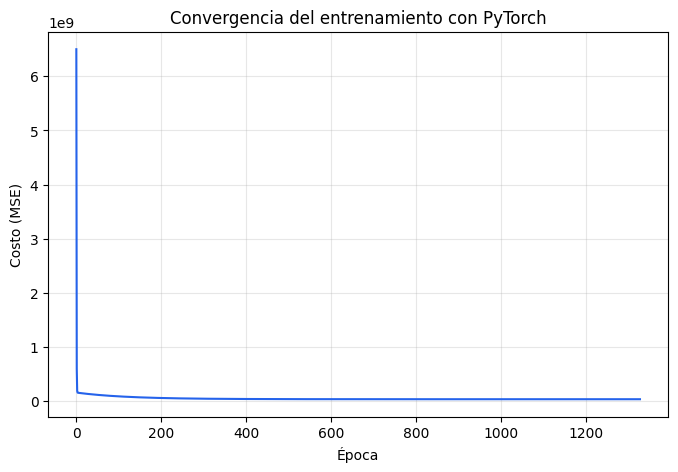

In [20]:
plt.figure(figsize=(8,5))
plt.plot(historial_costo, color='#2563eb')
plt.xlabel('Época')
plt.ylabel('Costo (MSE)')
plt.title('Convergencia del entrenamiento con PyTorch')
plt.grid(alpha=0.3)
plt.show()

## 7. Parámetros aprendidos y comparación con el Laboratorio 1 original

Se extraen los valores finales de `weight` y `bias` del modelo entrenado, y se comparan directamente contra los valores `b` y `w` que había obtenido el Laboratorio 1 original con su descenso de gradiente manual.

Como se explicó antes de construir este notebook: al ser la regresión lineal simple con error cuadrático medio un problema de optimización convexo (con un único mínimo posible), ambos enfoques deberían llegar a valores muy cercanos entre sí, aunque no necesariamente idénticos al último decimal, dado que PyTorch parte de una inicialización aleatoria distinta y usa precisión numérica de 32 bits en lugar de la precisión de 64 bits de Python puro.

In [21]:
b_pytorch = modelo.bias.item()
w_pytorch = modelo.weight.item()

b_original = 25792.18
w_original = 9449.97

print('Comparación de parámetros:')
print(f'{"":15s}{"Laboratorio 1 (manual)":>25s}{"Laboratorio 6 (PyTorch)":>25s}')
print(f'{"b (intercepto)":15s}{b_original:>25.2f}{b_pytorch:>25.2f}')
print(f'{"w (pendiente)":15s}{w_original:>25.2f}{w_pytorch:>25.2f}')

Comparación de parámetros:
                  Laboratorio 1 (manual)  Laboratorio 6 (PyTorch)
b (intercepto)                  25792.18                 25706.92
w (pendiente)                    9449.97                  9462.62


## 8. Guardado del modelo entrenado

Se guardan únicamente los parámetros del modelo (`state_dict`), siguiendo el mismo patrón visto en el notebook de clase sobre guardado de modelos en PyTorch. Esta es la forma más liviana y recomendada de guardar un modelo, ya que solo almacena los números aprendidos (`weight` y `bias`), no la definición completa de la arquitectura.

In [22]:
torch.save(modelo.state_dict(), 'lab1_modelo_salarios.pt')
print('Modelo guardado en lab1_modelo_salarios.pt')

Modelo guardado en lab1_modelo_salarios.pt


## 9. Inferencia sobre 10 nuevos valores de x

Se usan los mismos 10 valores de años de experiencia del Laboratorio 1 original, para poder comparar directamente las predicciones de ambos modelos sobre los mismos casos nuevos (nunca vistos durante el entrenamiento).

In [23]:
nuevos_x = [0.5, 2.5, 4.3, 5.5, 6.2, 7.0, 8.5, 9.9, 10.8, 11.5]
nuevos_x_tensor = torch.tensor(nuevos_x, dtype=torch.float32).view(-1, 1)

modelo.eval()
with torch.no_grad():
    predicciones = modelo(nuevos_x_tensor)

predicciones_originales = [b_original + w_original * x for x in nuevos_x]

print(f'{"x (años)":>10s}{"Predicción Lab1 (manual)":>28s}{"Predicción Lab6 (PyTorch)":>28s}')
for x, pred_orig, pred_pt in zip(nuevos_x, predicciones_originales, predicciones):
    print(f'{x:>10.1f}{pred_orig:>28,.2f}{pred_pt.item():>28,.2f}')

  x (años)    Predicción Lab1 (manual)   Predicción Lab6 (PyTorch)
       0.5                   30,517.17                   30,438.23
       2.5                   49,417.10                   49,363.46
       4.3                   66,427.05                   66,396.17
       5.5                   77,767.01                   77,751.31
       6.2                   84,381.99                   84,375.15
       7.0                   91,941.97                   91,945.24
       8.5                  106,116.92                  106,139.17
       9.9                  119,346.88                  119,386.83
      10.8                  127,851.86                  127,903.19
      11.5                  134,466.83                  134,527.02


## 10. Conclusiones

- El modelo entrenado con PyTorch llegó a valores de `b` y `w` muy cercanos a los del Laboratorio 1 original, lo cual era el resultado esperado: al ser la regresión lineal simple con error cuadrático medio un problema convexo (con un único mínimo posible), cualquier implementación correcta del descenso de gradiente manual o con PyTorch debería converger hacia la misma zona de solución.
- La diferencia principal no está en el resultado final, sino en cómo se llega a él: el Laboratorio 1 requería escribir a mano las fórmulas de las derivadas parciales de `b` y `w`, mientras que aquí `loss.backward()` las calcula automáticamente mediante `autograd`, sin importar qué tan complejo sea el modelo.
- Usar `Dataset` y `DataLoader` puede parecer innecesario para un dataset tan pequeño (30 filas), pero es la misma estructura que se necesitaría sin cambios si el dataset tuviera millones de filas, ya que `DataLoader` se encarga de dividir en lotes, mezclar los datos, y cargarlos de forma eficiente.
- Las predicciones sobre los 10 valores nuevos de `x` resultaron prácticamente iguales entre ambos enfoques, confirmando que el modelo de PyTorch aprendió la misma relación lineal entre años de experiencia y salario que el modelo manual del Laboratorio 1.